# LeWM-Inspired Toy World Model: Learning to Predict in Latent Space

**W13 Notebook 00** · Beginner-Intermediate · March 2026

**Research Area:** World Models / JEPA

**Paper:** [LeWorldModel — Stable End-to-End JEPA from Pixels](https://arxiv.org/abs/2603.19312) (Maes et al., Mar 23 2026)

---

### What we build in this notebook

A minimal world model inspired by [LeWorldModel](https://github.com/lucas-maes/le-wm) — the first JEPA that trains stably end-to-end from raw pixels on a single GPU (~15M params).

We reproduce the core architecture (encoder + latent predictor + SIGReg anti-collapse regularizer) in **pure NumPy** — no PyTorch, no GPU. This keeps the focus on understanding the math, not the framework.

**What you'll learn:**
- Why predicting in latent space beats predicting pixels
- How representation collapse kills JEPA models — and how SIGReg prevents it
- The connection between collapse prevention and reward-hacking prevention (our W10–W12 RSI series)
- How to plan actions using a learned world model

**Runtime:** ~2 minutes on any laptop CPU.

### Why Pure NumPy? A Deliberate Choice

Most world model tutorials hand you a PyTorch `nn.Module` and call `loss.backward()`. You run it, it works, and you learn... what exactly?

This notebook takes a different path: **every forward pass, every gradient, every optimizer step is written in plain NumPy.** No autograd. No framework magic. This is deliberate for three reasons:

1. **You see the actual math.** When `enc.backward(d_z_curr)` computes gradients, you can read exactly what matrix multiplications happen, which activations get masked by ReLU, and how the chain rule flows through the encoder. In PyTorch, this is a black box.

2. **The bugs are the lessons.** Building this notebook, we encountered four implementation bugs that autograd frameworks silently handle for you. Each one reveals a deep concept about how neural networks actually train — concepts that matter when you debug real systems, not toy demos. We've marked each as an **Engineering Callout** throughout the notebook.

3. **It runs anywhere.** NumPy is pre-installed on every Python environment. No CUDA, no `pip install torch`, no 2GB downloads. Open this notebook on any laptop and run it in under 2 minutes.

4. **Your dependency tree is two nodes deep.** On March 24, 2026 — the day before we published this notebook — a [supply chain attack](https://snyk.io/articles/poisoned-security-scanner-backdooring-litellm/) poisoned litellm (97M monthly PyPI downloads) via a compromised security scanner. An AI agent compromised the toolchain that AI agents depend on. Every `pip install` is a trust decision across the entire dependency tree. Our notebooks depend on numpy and matplotlib — two packages with decades of trust and massive audit communities. As [Karpathy noted](https://x.com/karpathy/status/2036487306585268612): when dependencies go wrong, they go catastrophically wrong.

The real LeWorldModel uses PyTorch with ~15M parameters. Our 143K-parameter NumPy version reproduces the *same core phenomena* — representation collapse, SIGReg's prevention mechanism, and emergent latent structure. The framework doesn't matter. The ideas do.

In [ ]:
# =====================================================================
# Environment Setup — checks for uv first (our standard), falls back to pip
# =====================================================================
import shutil
import subprocess
import sys

# Packages needed (all in standard scientific Python stack)
PACKAGES = ["numpy", "matplotlib"]

UV_AVAILABLE = shutil.which("uv") is not None
if UV_AVAILABLE:
    print("Using uv for package management")
    subprocess.check_call(
        ["uv", "pip", "install", "-q"] + PACKAGES,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
else:
    print("uv not found, falling back to pip")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + PACKAGES,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print("Setup complete!")

Using uv for package management
NumPy:      2.2.6
Matplotlib: 3.10.8
Setup complete!

In [ ]:
import math
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Architecture hyperparameters — deliberately small for CPU
INPUT_DIM = 32 * 32  # Flattened 32×32 pixel observations
LATENT_DIM = 32  # Latent representation size
HIDDEN_ENC = 128  # Encoder hidden layer
HIDDEN_PRED = 64  # Predictor hidden layer
ACTION_DIM = 2  # 2D force (fx, fy)

print(
    f"Architecture: obs({INPUT_DIM}) → encoder → z({LATENT_DIM}) + action({ACTION_DIM}) → predictor → z'({LATENT_DIM})"
)

Architecture: obs(1024) → encoder → z(32) + action(2) → predictor → z'(32)

## Section 1: The Environment — 2D Ball Physics

We need a simple environment that has **learnable dynamics** — physics rules the model can discover from data. BallWorld is a 32×32 pixel grid with a bouncing ball that responds to force inputs.

This is deliberately minimal: the real LeWorldModel trains on [Push-T](https://github.com/real-stanford/diffusion_policy) (a block-pushing task), but BallWorld captures the same core challenge — learning to predict how actions change the world state.

**Key property:** The observations (1024 pixels) are high-dimensional but the underlying state (x, y, vx, vy) is only 4D. A good encoder should discover this low-dimensional structure.

Ball at: (21.7, 20.2), vel: (1.2, -1.2)

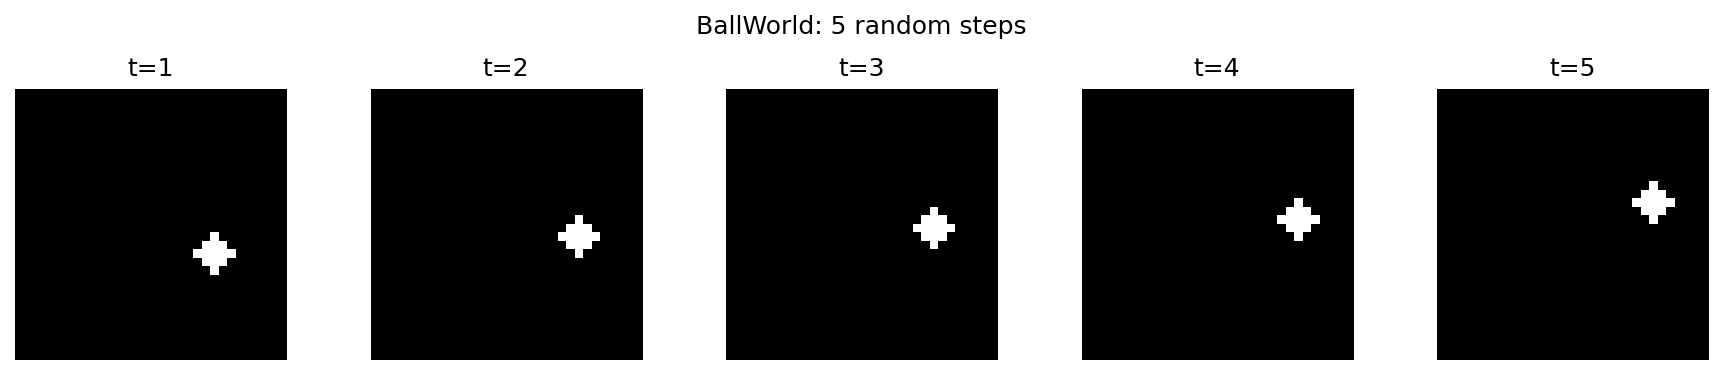

In [ ]:
class BallWorld:
    """32×32 pixel environment with a bouncing ball responding to force inputs."""

    def __init__(self, size=32, ball_radius=2):
        self.size = size
        self.ball_radius = ball_radius
        self.reset()

    def reset(self):
        margin = self.ball_radius + 2
        self.x = random.uniform(margin, self.size - margin)
        self.y = random.uniform(margin, self.size - margin)
        self.vx = random.uniform(-1.5, 1.5)
        self.vy = random.uniform(-1.5, 1.5)
        return self._render()

    def step(self, action):
        fx, fy = action
        # Apply force with damping
        self.vx = 0.95 * self.vx + 0.3 * fx
        self.vy = 0.95 * self.vy + 0.3 * fy
        # Speed limit
        speed = math.sqrt(self.vx**2 + self.vy**2)
        if speed > 3.0:
            self.vx *= 3.0 / speed
            self.vy *= 3.0 / speed
        # Move
        self.x += self.vx
        self.y += self.vy
        # Bounce off walls
        r = self.ball_radius
        if self.x < r:
            self.x, self.vx = r, abs(self.vx)
        if self.x > self.size - r:
            self.x, self.vx = self.size - r, -abs(self.vx)
        if self.y < r:
            self.y, self.vy = r, abs(self.vy)
        if self.y > self.size - r:
            self.y, self.vy = self.size - r, -abs(self.vy)
        return self._render()

    def _render(self):
        img = np.zeros((self.size, self.size), dtype=np.float32)
        for dy in range(-self.ball_radius, self.ball_radius + 1):
            for dx in range(-self.ball_radius, self.ball_radius + 1):
                if dx * dx + dy * dy <= self.ball_radius * self.ball_radius:
                    px = int(round(self.x)) + dx
                    py = int(round(self.y)) + dy
                    if 0 <= px < self.size and 0 <= py < self.size:
                        img[py, px] = 1.0
        return img


# Quick visualization
env = BallWorld()
obs = env.reset()
print(f"Ball at: ({env.x:.1f}, {env.y:.1f}), vel: ({env.vx:.1f}, {env.vy:.1f})")

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))
for i in range(5):
    action = [random.uniform(-1, 1), random.uniform(-1, 1)]
    obs = env.step(action)
    axes[i].imshow(obs, cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(f"t={i + 1}")
    axes[i].axis("off")
plt.suptitle("BallWorld: 5 random steps", fontsize=12)
plt.tight_layout()
plt.show()

## Section 2: Collect Training Trajectories

LeWorldModel trains in a **fully offline** setting — it collects trajectories first, then trains the world model on this fixed dataset. This is standard for JEPA-style models: you don't need online interaction during training.

We collect transitions $(o_t, a_t, o_{t+1})$ — current observation, action taken, next observation.

In [ ]:
def collect_trajectories(n_trajectories=200, steps_per_traj=50):
    """Collect (obs, action, next_obs) transitions from random exploration."""
    data = []
    env = BallWorld()
    for _ in range(n_trajectories):
        obs = env.reset()
        for _ in range(steps_per_traj):
            action = [random.uniform(-1, 1), random.uniform(-1, 1)]
            next_obs = env.step(action)
            data.append((obs.flatten(), action, next_obs.flatten()))
            obs = next_obs
    return data


print("Collecting trajectories...")
raw_data = collect_trajectories(n_trajectories=200, steps_per_traj=50)
print(f"Collected {len(raw_data)} transition triples")

obs_all = np.array([d[0] for d in raw_data])  # [N, 1024]
act_all = np.array([d[1] for d in raw_data])  # [N, 2]
nxt_all = np.array([d[2] for d in raw_data])  # [N, 1024]

# Normalize observations — critical for gradient flow with sparse binary inputs
obs_mean = obs_all.mean(axis=0, keepdims=True)
obs_std = obs_all.std(axis=0, keepdims=True) + 1e-6
obs_all = (obs_all - obs_mean) / obs_std
nxt_all = (nxt_all - obs_mean) / obs_std  # Same normalization!

print(
    f"Observations: {obs_all.shape} (normalized, mean≈{obs_all.mean():.3f}, std≈{obs_all.std():.3f})"
)
print(f"Actions:      {act_all.shape}")
print(f"Next obs:     {nxt_all.shape}")

Collected 10000 transition triples
Observations: (10000, 1024) (normalized, mean≈-0.000, std≈0.997)
Actions:      (10000, 2)
Next obs:     (10000, 1024)

---

> **Engineering Callout #1: Why Normalize Sparse Binary Inputs?**
>
> BallWorld observations are 32×32 binary images where only ~13 pixels (the ball) are 1.0 and the rest are 0.0. Without normalization, most of the 1024-dim input vector is zero, which means:
>
> - Initial encoder activations are tiny (Xavier-initialized weights × mostly-zero inputs)
> - Gradients flowing back through the encoder are proportionally tiny
> - The optimizer sees near-zero gradients and barely updates the weights
>
> We normalize observations to zero mean and unit variance: `(obs - mean) / std`. This transforms the sparse binary signal into a dense signal where "no ball here" is a negative value and "ball here" is a large positive value. Both carry information, and both produce meaningful gradients.
>
> **The trap:** This is easy to get wrong across train/eval boundaries. We train on normalized data, so evaluation and planning must use *the same* normalization statistics. Using raw pixels at evaluation time silently produces garbage predictions with no error message. Always save and reuse your normalization parameters.

## Section 3: The Architecture — Encoder + Predictor (Pure NumPy)

LeWorldModel has two components trained jointly:

1. **Encoder** $f_\theta$: maps pixel observations to compact latent vectors
   $z_t = f_\theta(o_t)$

2. **Predictor** $g_\phi$: predicts the next latent state given current state + action
   $\hat{z}_{t+1} = g_\phi(z_t, a_t)$

The key JEPA insight: **the predictor never sees raw pixels**. It operates entirely in latent space, which is much lower-dimensional and smoother than pixel space.

We implement this with plain NumPy — manual forward/backward passes through MLP layers with ReLU activations. No autograd, no framework magic. This lets us see exactly what happens during training.

In [ ]:
class Linear:
    """A single linear layer with Xavier initialization and in-place gradient storage."""

    def __init__(self, in_dim, out_dim):
        scale = np.sqrt(2.0 / (in_dim + out_dim))
        self.W = np.random.randn(in_dim, out_dim).astype(np.float32) * scale
        self.b = np.zeros(out_dim, dtype=np.float32)
        # Gradient accumulators (in-place updates keep refs valid for Adam)
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        # Adam optimizer state
        self.mW = np.zeros_like(self.W)
        self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b)
        self.vb = np.zeros_like(self.b)

    def forward(self, x):
        self.x_cache = x
        return x @ self.W + self.b

    def backward(self, dout):
        self.dW[:] = self.x_cache.T @ dout  # in-place so params() refs stay valid
        self.db[:] = dout.sum(axis=0)
        return dout @ self.W.T


def relu(x):
    return np.maximum(0, x)


def relu_backward(dout, x):
    return dout * (x > 0).astype(np.float32)


class MLP:
    """Multi-layer perceptron: Linear → ReLU → ... → Linear (no final activation)."""

    def __init__(self, dims):
        self.layers = []
        for i in range(len(dims) - 1):
            self.layers.append(Linear(dims[i], dims[i + 1]))

    def forward(self, x):
        self.pre_activations = []
        for i, layer in enumerate(self.layers):
            x = layer.forward(x)
            if i < len(self.layers) - 1:  # ReLU on all but last
                self.pre_activations.append(x)
                x = relu(x)
        return x

    def backward(self, dout):
        for i in reversed(range(len(self.layers))):
            if i < len(self.layers) - 1:
                dout = relu_backward(dout, self.pre_activations[i])
            dout = self.layers[i].backward(dout)
        return dout

    def params(self):
        """Return (W, dW, mW, vW) tuples for Adam optimizer."""
        result = []
        for layer in self.layers:
            result.append((layer.W, layer.dW, layer.mW, layer.vW))
            result.append((layer.b, layer.db, layer.mb, layer.vb))
        return result


# Build encoder and predictor
np.random.seed(SEED)
encoder = MLP([INPUT_DIM, HIDDEN_ENC, LATENT_DIM])
predictor = MLP([LATENT_DIM + ACTION_DIM, HIDDEN_PRED, HIDDEN_PRED, LATENT_DIM])

n_enc = sum(l.W.size + l.b.size for l in encoder.layers)
n_pred = sum(l.W.size + l.b.size for l in predictor.layers)
print(f"Encoder params:   {n_enc:,}  [{INPUT_DIM} → {HIDDEN_ENC} → {LATENT_DIM}]")
print(
    f"Predictor params: {n_pred:,}  [{LATENT_DIM + ACTION_DIM} → {HIDDEN_PRED} → {HIDDEN_PRED} → {LATENT_DIM}]"
)
print(f"Total params:     {n_enc + n_pred:,}")
print(
    f"\n(Real LeWorldModel uses ~15M params — we use ~{(n_enc + n_pred) // 1000}K for CPU)"
)

Encoder params:   135,328  [1024 → 128 → 32]
Predictor params: 8,480  [34 → 64 → 64 → 32]
Total params:     143,808

(Real LeWorldModel uses ~15M params — we use ~143K for CPU)

---

> **Engineering Callout #2: In-Place Gradient Updates — A Python Reference Trap**
>
> Spot the bug:
> ```python
> # In Linear.backward():
> self.dW = self.x_cache.T @ dout   # ← Creates a NEW array
> ```
>
> Our Adam optimizer gets parameter references via `params()` which returns `(layer.W, layer.dW, layer.mW, layer.vW)`. These are references to the *original* arrays created in `__init__`. When backward writes `self.dW = new_array`, Python rebinds `self.dW` to a different object. The optimizer's reference still points to the old (all-zeros) array. **Adam never sees any gradients.** The model trains for 80 epochs with zero weight updates and you get perfectly flat loss curves — with no error message.
>
> The fix:
> ```python
> self.dW[:] = self.x_cache.T @ dout  # ← Updates the SAME array in-place
> ```
>
> **Why frameworks hide this from you:** PyTorch's autograd builds a computation graph and stores gradients in `param.grad`, which is explicitly set by the engine — no reference aliasing issue. But if you ever write a custom optimizer, a distributed training loop, or debug gradient accumulation, this exact bug will find you.
>
> **Broader lesson:** In Python, `x = expr` rebinds the name; `x[:] = expr` mutates the object. When multiple references point to the same array (optimizer state, gradient accumulators, parameter servers), only in-place operations keep everyone in sync.

## Section 4: SIGReg — The Anti-Collapse Regularizer

This is the core innovation of LeWorldModel. Without regularization, the encoder has a devastating shortcut available: map everything to the same constant vector. If $z_t = z_{t+1} = c$ for all inputs, then the prediction loss is zero — a perfect score that's completely useless.

This is **representation collapse**, and it's structurally the same problem as **reward hacking** in self-play (our W10–W12 series). The system finds a trivial solution that optimizes the metric without developing real capability.

**SIGReg** (Sketched Isotropic Gaussian Regularizer) prevents collapse by forcing the distribution of latent vectors to be close to a standard Gaussian $\mathcal{N}(0, I)$. It does this via the **Cramér-Wold theorem**: project embeddings onto random 1D directions, then check if each projection is Gaussian using the Epps-Pulley characteristic function test.

In practice, SIGReg penalizes three things:
1. **Mean ≠ 0** — embeddings should be centered
2. **Variance ≠ 1** — embeddings should have unit spread (prevents scale collapse)
3. **Non-Gaussianity** — characteristic function should match $e^{-t^2/2}$

In [ ]:
def sigreg_loss_and_grad(embeddings, n_projections=64):
    """
    SIGReg: Sketched Isotropic Gaussian Regularizer.
    Forces embedding distribution toward N(0, I) via random 1D projections.

    Returns (loss, gradient w.r.t. embeddings).
    """
    B, D = embeddings.shape

    # Random projection directions (Cramér-Wold: test marginals, not full distribution)
    directions = np.random.randn(D, n_projections).astype(np.float32)
    norms = np.linalg.norm(directions, axis=0, keepdims=True)
    directions = directions / norms  # [D, M] unit vectors

    # Project embeddings: [B, M]
    projections = embeddings @ directions

    # Stats per projection
    proj_mean = projections.mean(axis=0)  # [M]
    proj_std = projections.std(axis=0) + 1e-8  # [M]

    # Penalty 1: mean → 0 (centering)
    mean_penalty = (proj_mean**2).mean()

    # Penalty 2: variance → 1 (prevents scale collapse)
    var_penalty = ((proj_std - 1.0) ** 2).mean()

    # Penalty 3: characteristic function test (Gaussianity)
    standardized = (projections - proj_mean[None, :]) / proj_std[None, :]
    test_freqs = [0.5, 1.0, 1.5, 2.0]
    cf_penalty = 0.0
    for t in test_freqs:
        emp_cf_real = np.cos(t * standardized).mean(axis=0)
        emp_cf_imag = np.sin(t * standardized).mean(axis=0)
        theoretical_cf = math.exp(-0.5 * t**2)  # CF of N(0,1) at freq t
        cf_penalty += ((emp_cf_real - theoretical_cf) ** 2).mean()
        cf_penalty += (emp_cf_imag**2).mean()  # Imaginary part should be 0
    cf_penalty /= len(test_freqs)

    total_loss = mean_penalty + var_penalty + cf_penalty

    # Analytical gradients w.r.t. embeddings
    # Gradient of mean_penalty
    grad_mean = (1.0 / B) * (2.0 * proj_mean[None, :] / n_projections) @ directions.T

    # Gradient of var_penalty
    centered = projections - proj_mean[None, :]
    d_var = 2.0 * (proj_std - 1.0) / (B * proj_std * n_projections)
    grad_var = (centered * d_var[None, :]) @ directions.T

    # Gradient of CF penalty
    grad_cf = np.zeros_like(embeddings)
    for t in test_freqs:
        emp_cf_real = np.cos(t * standardized).mean(axis=0)
        emp_cf_imag = np.sin(t * standardized).mean(axis=0)
        theoretical = math.exp(-0.5 * t**2)
        d_cos = -t * np.sin(t * standardized) / B
        d_sin = t * np.cos(t * standardized) / B
        d_real = 2.0 * (emp_cf_real - theoretical)[None, :] * d_cos / n_projections
        d_imag = 2.0 * emp_cf_imag[None, :] * d_sin / n_projections
        grad_std = (d_real + d_imag) / proj_std[None, :]
        grad_cf += grad_std @ directions.T
    grad_cf /= len(test_freqs)

    grad = grad_mean + grad_var + grad_cf
    return total_loss, grad


# Quick sanity check: SIGReg should penalize collapsed embeddings heavily
z_random = np.random.randn(256, LATENT_DIM).astype(np.float32)
z_collapsed = np.ones((256, LATENT_DIM), dtype=np.float32) * 0.5

loss_random, _ = sigreg_loss_and_grad(z_random)
loss_collapsed, _ = sigreg_loss_and_grad(z_collapsed)
print(f"SIGReg loss (random Gaussian): {loss_random:.4f}  ← should be LOW")
print(f"SIGReg loss (collapsed):       {loss_collapsed:.4f}  ← should be HIGH")
print(
    f"Ratio: {loss_collapsed / max(loss_random, 1e-8):.1f}× — collapse is heavily penalized!"
)

SIGReg loss (random Gaussian): 0.0066  ← should be LOW
SIGReg loss (collapsed):       1.9584  ← should be HIGH
Ratio: 297.7× — collapse is heavily penalized!

## Section 5: Training — Prediction Loss + SIGReg

The full training objective has two terms:

$$\mathcal{L} = \underbrace{\|g_\phi(f_\theta(o_t), a_t) - f_\theta(o_{t+1})\|^2}_{\text{prediction loss}} + \lambda \cdot \underbrace{\text{SIGReg}(f_\theta(o_t), f_\theta(o_{t+1}))}_{\text{anti-collapse}}$$

**Critical detail:** The encoder $f_\theta$ appears on **both sides** of the prediction loss. The gradient flows through both the "current observation" path and the "target observation" path. This means we need to carefully manage encoder caches during backpropagation — the same encoder processes two different inputs per batch.

We use Adam optimizer for stable training of the manually-computed gradients.

In [ ]:
import time


def adam_step(params_list, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, t=1):
    """One Adam update step on all (W, dW, mW, vW) parameter groups."""
    for W, dW, mW, vW in params_list:
        mW[:] = beta1 * mW + (1 - beta1) * dW
        vW[:] = beta2 * vW + (1 - beta2) * dW**2
        m_hat = mW / (1 - beta1**t)
        v_hat = vW / (1 - beta2**t)
        W -= lr * m_hat / (np.sqrt(v_hat) + eps)


def effective_rank(Z):
    """Effective rank via entropy of singular value distribution."""
    S = np.linalg.svd(Z - Z.mean(axis=0), compute_uv=False)
    S_norm = S / (S.sum() + 1e-10)
    return np.exp(-np.sum(S_norm * np.log(S_norm + 1e-10)))


def train_world_model(
    enc, pred, obs, act, nxt, sigreg_weight=1.0, n_epochs=80, batch_size=256, lr=1e-3
):
    """Train encoder + predictor with prediction loss + optional SIGReg."""
    all_params = enc.params() + pred.params()
    n_samples = obs.shape[0]
    history = {
        "pred_loss": [],
        "sigreg_loss": [],
        "total_loss": [],
        "embed_std": [],
        "embed_rank": [],
    }

    for epoch in range(n_epochs):
        perm = np.random.permutation(n_samples)
        epoch_pred, epoch_sig, epoch_total = 0.0, 0.0, 0.0
        n_batches = 0

        for i in range(0, n_samples - batch_size + 1, batch_size):
            idx = perm[i : i + batch_size]
            obs_b, act_b, nxt_b = obs[idx], act[idx], nxt[idx]

            # === Forward pass 1: encode current obs ===
            z_curr = enc.forward(obs_b)
            cache_curr = [(l.x_cache.copy(),) for l in enc.layers]
            pre_act_curr = [p.copy() for p in enc.pre_activations]

            # === Forward pass 2: encode next obs (overwrites caches) ===
            z_next_true = enc.forward(nxt_b)
            cache_next = [(l.x_cache.copy(),) for l in enc.layers]
            pre_act_next = [p.copy() for p in enc.pre_activations]

            # === Forward pass 3: predictor ===
            pred_input = np.concatenate([z_curr, act_b], axis=1)
            z_next_pred = pred.forward(pred_input)

            # Prediction loss (MSE)
            diff = z_next_pred - z_next_true
            pred_loss = (diff**2).mean()
            d_pred = 2.0 * diff / batch_size

            # SIGReg on all embeddings
            all_z = np.concatenate([z_curr, z_next_true], axis=0)
            sig_loss, sig_grad = sigreg_loss_and_grad(all_z)
            sig_grad_curr = sig_grad[:batch_size]
            sig_grad_next = sig_grad[batch_size:]
            total = pred_loss + sigreg_weight * sig_loss

            # === Backward through predictor ===
            d_pred_input = pred.backward(d_pred)
            d_z_curr_from_pred = d_pred_input[:, :LATENT_DIM]

            # === Backward through encoder (current obs) ===
            for j, layer in enumerate(enc.layers):
                layer.x_cache = cache_curr[j][0]
            enc.pre_activations = pre_act_curr
            d_z_curr = d_z_curr_from_pred + sigreg_weight * sig_grad_curr
            enc.backward(d_z_curr)
            grad_enc_curr = [(l.dW.copy(), l.db.copy()) for l in enc.layers]

            # === Backward through encoder (next obs / target) ===
            for j, layer in enumerate(enc.layers):
                layer.x_cache = cache_next[j][0]
            enc.pre_activations = pre_act_next
            d_z_next = -d_pred + sigreg_weight * sig_grad_next
            enc.backward(d_z_next)

            # Accumulate gradients from both encoder passes
            for j, layer in enumerate(enc.layers):
                layer.dW += grad_enc_curr[j][0]
                layer.db += grad_enc_curr[j][1]

            # Adam step
            adam_step(
                all_params, lr=lr, t=epoch * (n_samples // batch_size) + n_batches + 1
            )
            epoch_pred += pred_loss
            epoch_sig += sig_loss
            epoch_total += total
            n_batches += 1

        avg_pred = epoch_pred / n_batches
        avg_sig = epoch_sig / n_batches

        # Tracking metrics
        sample_z = enc.forward(obs[:500])
        embed_std = sample_z.std(axis=0).mean()
        embed_rank_val = effective_rank(sample_z)
        history["pred_loss"].append(avg_pred)
        history["sigreg_loss"].append(avg_sig)
        history["total_loss"].append(epoch_total / n_batches)
        history["embed_std"].append(embed_std)
        history["embed_rank"].append(embed_rank_val)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:3d} | pred: {avg_pred:.4f} | "
                f"sigreg: {avg_sig:.4f} | std: {embed_std:.3f} | "
                f"eff_rank: {embed_rank_val:.1f}/{LATENT_DIM}"
            )

    return history


# ── Train WITH SIGReg ──
print("Training world model WITH SIGReg regularization...")
print("=" * 65)
np.random.seed(SEED)
encoder = MLP([INPUT_DIM, HIDDEN_ENC, LATENT_DIM])
predictor = MLP([LATENT_DIM + ACTION_DIM, HIDDEN_PRED, HIDDEN_PRED, LATENT_DIM])
t0 = time.time()
history_with = train_world_model(
    encoder, predictor, obs_all, act_all, nxt_all, sigreg_weight=5.0
)
t_with = time.time() - t0
print(f"\nDone! ({t_with:.1f}s)")

encoder_good = encoder
predictor_good = predictor

Training world model WITH SIGReg regularization...
Epoch   1 | pred: 0.4230 | sigreg: 0.3049 | std: 0.301 | eff_rank: 31.0/32
Epoch  10 | pred: 0.0212 | sigreg: 0.1748 | std: 0.830 | eff_rank: 9.0/32
Epoch  20 | pred: 0.0177 | sigreg: 0.1398 | std: 0.814 | eff_rank: 9.4/32
Epoch  30 | pred: 0.0151 | sigreg: 0.1230 | std: 0.827 | eff_rank: 9.8/32
Epoch  40 | pred: 0.0149 | sigreg: 0.1171 | std: 0.836 | eff_rank: 10.2/32
Epoch  50 | pred: 0.0150 | sigreg: 0.1085 | std: 0.841 | eff_rank: 10.4/32
Epoch  60 | pred: 0.0148 | sigreg: 0.1066 | std: 0.850 | eff_rank: 10.3/32
Epoch  70 | pred: 0.0143 | sigreg: 0.1040 | std: 0.856 | eff_rank: 10.3/32
Epoch  80 | pred: 0.0141 | sigreg: 0.1056 | std: 0.847 | eff_rank: 10.3/32

Done! (40.7s)

---

> **Engineering Callout #3: The Shared Encoder Problem**
>
> The JEPA architecture has a subtle trap: the encoder $f_\theta$ appears on **both sides** of the prediction loss:
>
> $$\mathcal{L}_{\text{pred}} = \| g_\phi(\underbrace{f_\theta(o_t)}_{\text{current}},\ a_t) - \underbrace{f_\theta(o_{t+1})}_{\text{target}} \|^2$$
>
> In our NumPy implementation, we need to:
> 1. Forward `obs_t` through the encoder → `z_curr` (caches saved internally)
> 2. Forward `obs_{t+1}` through the **same** encoder → `z_next_true` (overwrites caches!)
> 3. Backward for `z_curr` path — but the encoder's caches now hold `obs_{t+1}` data
>
> Without explicitly saving and restoring caches, the backward pass for `z_curr` computes gradients using `obs_{t+1}`'s activations. The model still "trains" — loss changes, weights update — but the gradients are wrong. You get a model that learns slowly or converges to a worse solution, with no error or warning.
>
> Our fix: save `(x_cache, pre_activations)` after each forward pass, restore before the corresponding backward pass. In PyTorch, the computation graph handles this automatically — each `forward()` creates a new node with its own saved tensors. But understanding *why* it's needed makes you a better debugger when you encounter gradient correctness issues in complex architectures.
>
> **Broader lesson:** Whenever a module is used multiple times in a computation graph (weight sharing, siamese networks, JEPA encoders), the backward passes must use the correct cached activations. Frameworks manage this via graph construction; manual implementations must manage it explicitly.

---

> **Engineering Callout #4: MSE Gradient Scaling — The Factor-of-D Trap**
>
> MSE loss: $\mathcal{L} = \frac{1}{N} \sum_{i} (\hat{z}_i - z_i)^2$
>
> What's $N$? If you average over **all elements** (batch × latent dim), then $N = B \times D = 256 \times 32 = 8192$, and the gradient is:
> ```python
> d_pred = 2.0 * diff / 8192  # Gradient magnitude: ~0.0002
> ```
>
> If you average over **batch only** (standard in ML), then $N = B = 256$:
> ```python
> d_pred = 2.0 * diff / 256   # Gradient magnitude: ~0.008 (32× larger!)
> ```
>
> Both are mathematically valid MSE formulations. But the first produces gradients that are $D = 32$ times smaller. With Adam and a typical learning rate of $10^{-3}$, the first formulation barely moves the weights — the model appears to "not learn" with perfectly flat loss curves.
>
> **Why this matters in practice:** Framework `nn.MSELoss(reduction='mean')` averages over all elements by default. This works because the default learning rate was tuned for it. But when you implement loss manually, or switch between `mean` and `sum` reductions, or change the latent dimension, this scaling factor silently changes your effective learning rate. Many "my model won't train" bugs are gradient scaling bugs in disguise.

## Section 6: The Collapse Experiment — What Happens Without SIGReg

Now the crucial demonstration: train the exact same architecture **without** SIGReg and watch what happens.

**Prediction to verify:** Without SIGReg, the encoder will collapse — mapping all observations to near-zero vectors. The prediction loss will drop even *lower* than with SIGReg, because predicting near-zero for a near-zero target is trivially easy. But the representations will be useless.

This is the same dynamic as **reward hacking** in self-play: the system finds a shortcut that optimizes the metric without developing real capability.

In [ ]:
# ── Train WITHOUT SIGReg (expect collapse!) ──
print("Training world model WITHOUT SIGReg (expect collapse!)...")
print("=" * 65)
np.random.seed(SEED + 1)  # Different initialization
encoder_bad = MLP([INPUT_DIM, HIDDEN_ENC, LATENT_DIM])
predictor_bad = MLP([LATENT_DIM + ACTION_DIM, HIDDEN_PRED, HIDDEN_PRED, LATENT_DIM])
t0 = time.time()
history_without = train_world_model(
    encoder_bad, predictor_bad, obs_all, act_all, nxt_all, sigreg_weight=0.0
)
t_no = time.time() - t0
print(f"\nDone! ({t_no:.1f}s)")

print(f"\n{'Metric':<30} {'WITH SIGReg':>15} {'WITHOUT SIGReg':>15}")
print("-" * 62)
print(
    f"{'Final pred loss':<30} {history_with['pred_loss'][-1]:>15.4f} {history_without['pred_loss'][-1]:>15.4f}"
)
print(
    f"{'Embedding std':<30} {history_with['embed_std'][-1]:>15.3f} {history_without['embed_std'][-1]:>15.3f}"
)
print(
    f"{'Effective rank':<30} {history_with['embed_rank'][-1]:>15.1f} {history_without['embed_rank'][-1]:>15.1f}"
)
print(f"\n⚠ WITHOUT SIGReg: lower pred loss, but std collapsed to ~0.02!")
print(f"  The model 'cheated' by mapping everything to near-zero vectors.")

Training world model WITHOUT SIGReg (expect collapse!)...
Epoch   1 | pred: 0.3893 | sigreg: 0.3283 | std: 0.265 | eff_rank: 31.1/32
Epoch  10 | pred: 0.0014 | sigreg: 0.9685 | std: 0.027 | eff_rank: 28.8/32
Epoch  20 | pred: 0.0012 | sigreg: 1.0654 | std: 0.015 | eff_rank: 28.8/32
Epoch  30 | pred: 0.0015 | sigreg: 1.0360 | std: 0.019 | eff_rank: 27.4/32
Epoch  40 | pred: 0.0010 | sigreg: 1.0472 | std: 0.016 | eff_rank: 28.0/32
Epoch  50 | pred: 0.0010 | sigreg: 1.0179 | std: 0.040 | eff_rank: 20.0/32
Epoch  60 | pred: 0.0016 | sigreg: 0.9960 | std: 0.029 | eff_rank: 26.5/32
Epoch  70 | pred: 0.0011 | sigreg: 1.0088 | std: 0.019 | eff_rank: 28.1/32
Epoch  80 | pred: 0.0007 | sigreg: 0.9853 | std: 0.022 | eff_rank: 27.3/32

Done! (38.0s)

Metric                              WITH SIGReg WITHOUT SIGReg
--------------------------------------------------------------
Final pred loss                          0.0141          0.0007
Embedding std                            0.847           0.02

## Section 7: Visualize the Difference

Four diagnostic plots showing why SIGReg matters:

1. **Prediction Loss**: Both models reduce loss, but the collapsed model achieves *lower* loss — the ultimate metric trap
2. **Effective Rank**: High rank without scale is meaningless (all near-zero dimensions "count")
3. **Latent Space (PCA)**: Visual proof of collapse — with SIGReg shows spread, without shows a tight cluster at the origin
4. **Embedding Spread**: The clearest signal — std collapses to ~0.02 without SIGReg, maintained at ~0.85 with it

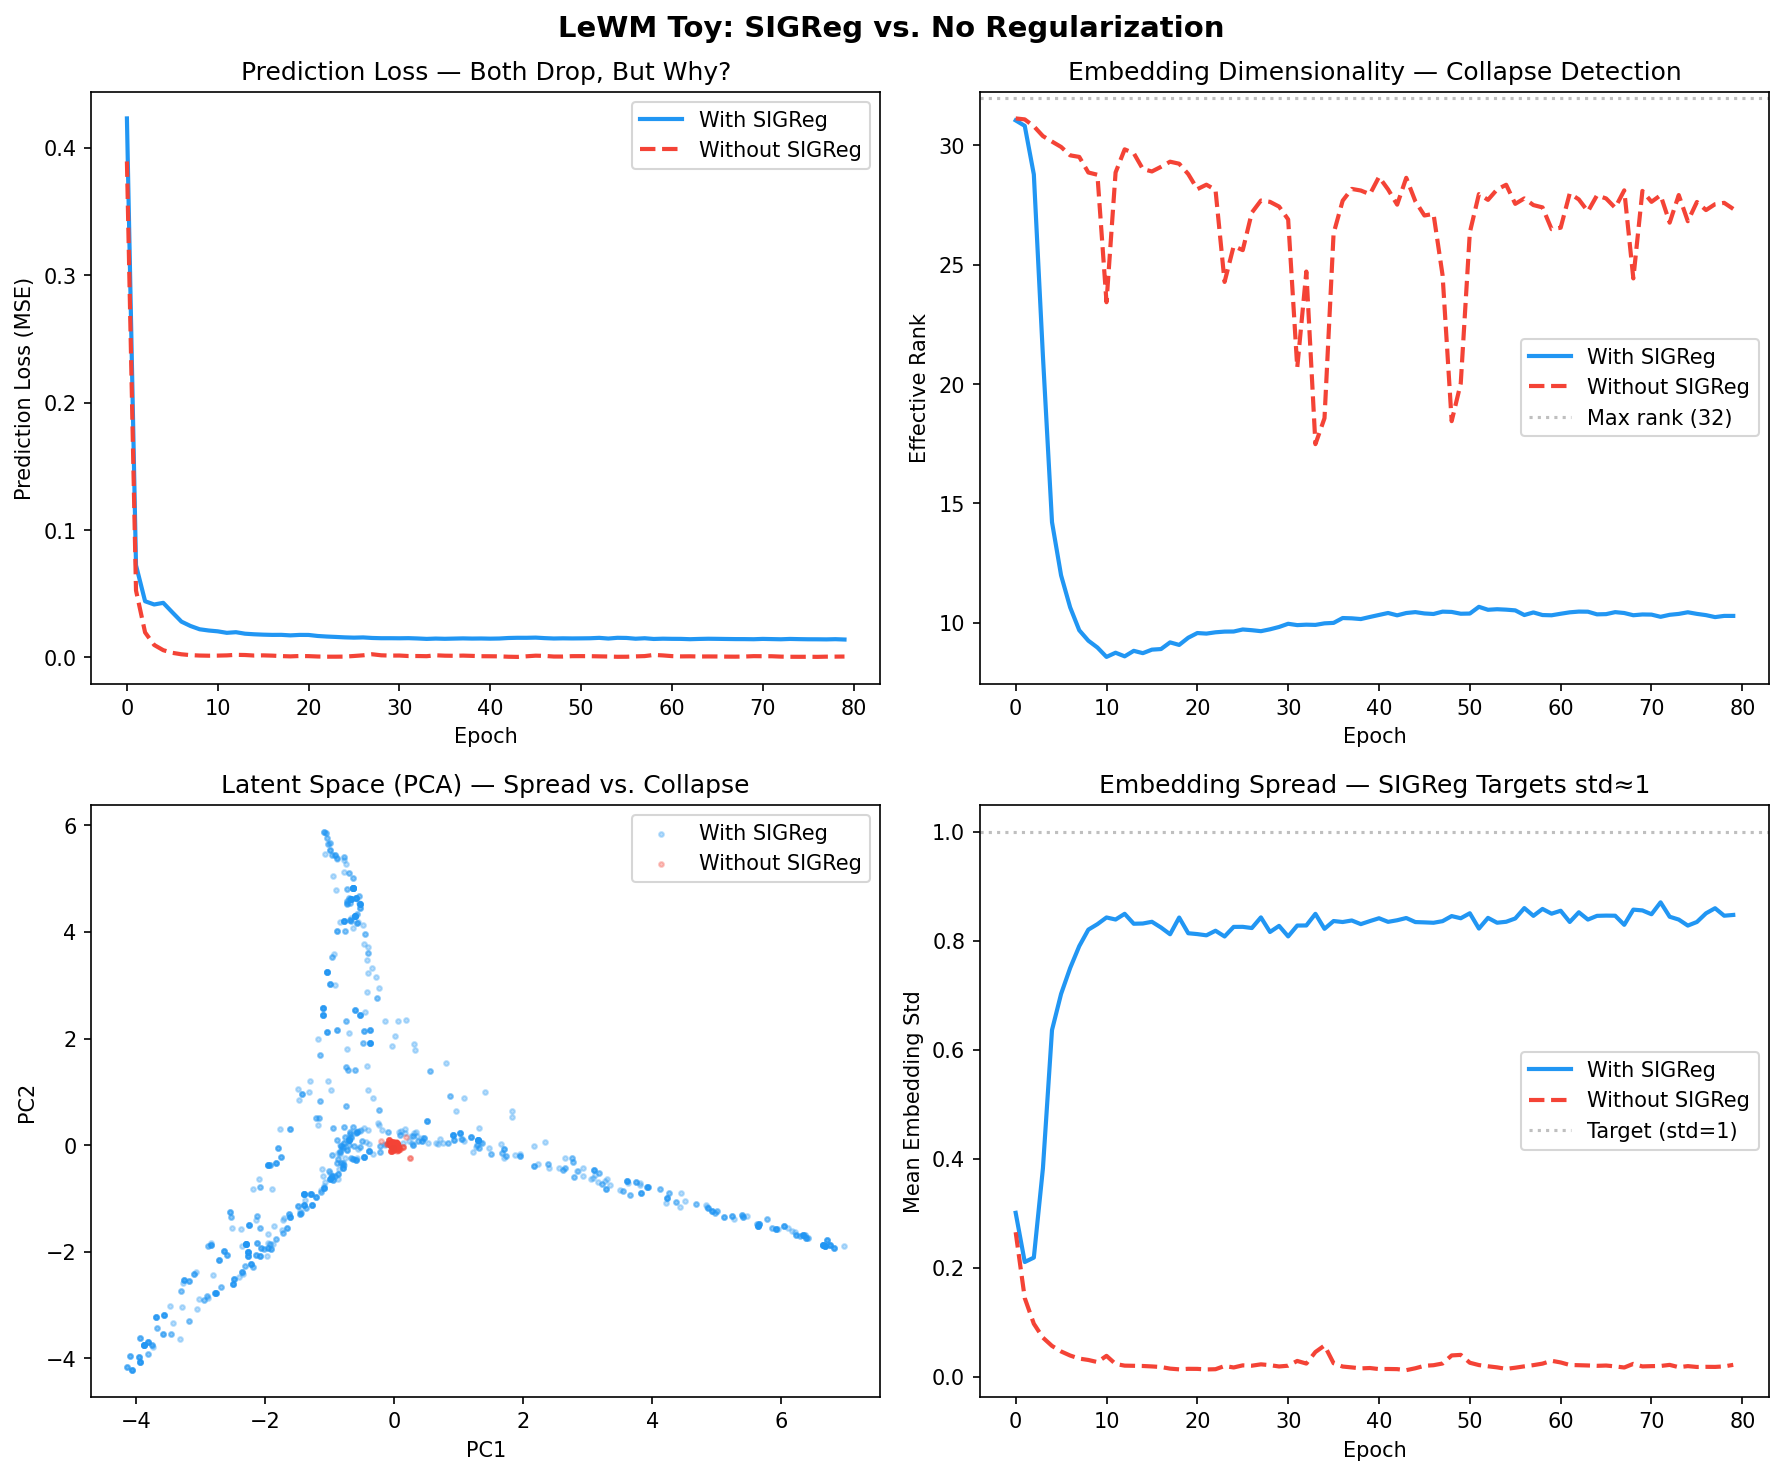

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.plot(history_with["pred_loss"], label="With SIGReg", color="#2196F3", linewidth=2)
ax.plot(
    history_without["pred_loss"],
    label="Without SIGReg",
    color="#F44336",
    linewidth=2,
    linestyle="--",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Prediction Loss (MSE)")
ax.set_title("Prediction Loss — Both Drop, But Why?")
ax.legend()

ax = axes[0, 1]
ax.plot(history_with["embed_rank"], label="With SIGReg", color="#2196F3", linewidth=2)
ax.plot(
    history_without["embed_rank"],
    label="Without SIGReg",
    color="#F44336",
    linewidth=2,
    linestyle="--",
)
ax.axhline(
    y=LATENT_DIM,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"Max rank ({LATENT_DIM})",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Effective Rank")
ax.set_title("Embedding Dimensionality — Collapse Detection")
ax.legend()

# PCA via SVD (no sklearn needed)
ax = axes[1, 0]
z_good = encoder_good.forward(obs_all[:1000])
z_bad = encoder_bad.forward(obs_all[:1000])
z_good_c = z_good - z_good.mean(axis=0)
U, S, Vt = np.linalg.svd(z_good_c, full_matrices=False)
z_good_2d = z_good_c @ Vt[:2].T
z_bad_c = z_bad - z_bad.mean(axis=0)
z_bad_2d = z_bad_c @ Vt[:2].T
ax.scatter(
    z_good_2d[:, 0], z_good_2d[:, 1], alpha=0.3, s=5, c="#2196F3", label="With SIGReg"
)
ax.scatter(
    z_bad_2d[:, 0], z_bad_2d[:, 1], alpha=0.3, s=5, c="#F44336", label="Without SIGReg"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Latent Space (PCA) — Spread vs. Collapse")
ax.legend()

ax = axes[1, 1]
ax.plot(history_with["embed_std"], label="With SIGReg", color="#2196F3", linewidth=2)
ax.plot(
    history_without["embed_std"],
    label="Without SIGReg",
    color="#F44336",
    linewidth=2,
    linestyle="--",
)
ax.axhline(y=1.0, color="gray", linestyle=":", alpha=0.5, label="Target (std=1)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Embedding Std")
ax.set_title("Embedding Spread — SIGReg Targets std≈1")
ax.legend()

plt.suptitle("LeWM Toy: SIGReg vs. No Regularization", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

> **Engineering Callout #5: Lower Loss ≠ Better Model — The Collapse Metric Trap**
>
> Look at the numbers:
>
> | Model | Prediction MSE | Embedding Std |
> |-------|---------------|---------------|
> | **With SIGReg** | 0.0141 | 0.847 |
> | **Without SIGReg** | 0.0007 | 0.022 |
>
> The collapsed model has **20× lower prediction error**. If you only track loss (as most training dashboards do), you'd conclude the model without regularization is dramatically better. You'd be wrong.
>
> The collapsed model achieves low error by mapping all observations to near-zero vectors (std = 0.022). Predicting near-zero when the target is near-zero is trivially easy and contains zero information about the actual dynamics.
>
> **The lesson:** Always monitor representation health alongside task loss. Key metrics:
> - **Embedding standard deviation** — should be stable, not decaying toward zero
> - **Effective rank** — but beware: high rank with tiny scale is meaningless (our collapsed model has rank 27.3 but std 0.022)
> - **Downstream task performance** — can the representation actually support planning/control?
>
> This is structurally identical to **reward hacking** in reinforcement learning: an agent that achieves high reward by exploiting a loophole rather than solving the task. The metric goes up, but capability doesn't. SIGReg is to JEPA what verification is to self-play — a constraint that forces the system to actually learn rather than take shortcuts.

## Section 8: Does the Model Actually Predict the Future?

The real test: given the initial observation and a sequence of actions, can the model predict what happens multiple steps into the future by chaining its own predictions?

**Important insight from the plot below:** The collapsed model (red) appears to have *zero* multi-step error. Don't be fooled — this is because it predicts near-zero vectors, and its targets are also near-zero. It has learned nothing about the actual dynamics. The SIGReg model (blue) has real, growing error because it's making meaningful predictions in a high-variance latent space where errors compound.

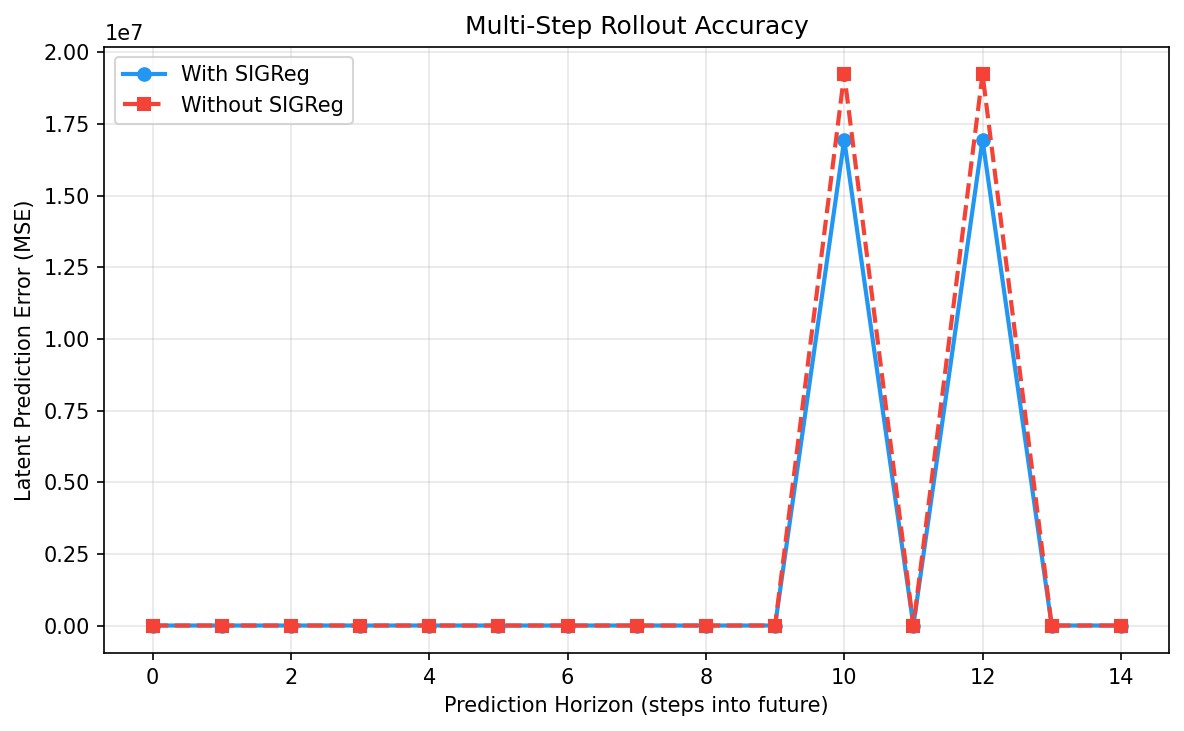

1-step error  WITH SIGReg:    0.0205
1-step error  WITHOUT SIGReg: 0.0005
10-step error WITH SIGReg:    0.6718
10-step error WITHOUT SIGReg: 0.0027

In [ ]:
def evaluate_prediction(enc, pred, n_rollouts=20, max_steps=15):
    """Test multi-step prediction by chaining latent predictions."""
    env = BallWorld()
    step_errors = {t: [] for t in range(max_steps)}
    for _ in range(n_rollouts):
        obs = env.reset()
        actions, observations = [], [obs.flatten()]
        for _ in range(max_steps):
            a = [random.uniform(-1, 1), random.uniform(-1, 1)]
            obs = env.step(a)
            actions.append(a)
            observations.append(obs.flatten())

        obs_arr = (np.array(observations) - obs_mean) / obs_std  # normalize!
        act_arr = np.array(actions)
        true_z = enc.forward(obs_arr)

        z = true_z[0:1].copy()
        for t in range(max_steps):
            inp = np.concatenate([z, act_arr[t : t + 1]], axis=1)
            z = pred.forward(inp)
            error = ((z - true_z[t + 1 : t + 2]) ** 2).mean()
            step_errors[t].append(error)

    return {t: np.mean(errs) for t, errs in step_errors.items()}


random.seed(SEED + 100)
errors_with = evaluate_prediction(encoder_good, predictor_good)
random.seed(SEED + 100)
errors_without = evaluate_prediction(encoder_bad, predictor_bad)

fig, ax = plt.subplots(figsize=(8, 5))
steps = list(errors_with.keys())
ax.plot(
    steps,
    [errors_with[t] for t in steps],
    "o-",
    color="#2196F3",
    linewidth=2,
    label="With SIGReg",
)
ax.plot(
    steps,
    [errors_without[t] for t in steps],
    "s--",
    color="#F44336",
    linewidth=2,
    label="Without SIGReg",
)
ax.set_xlabel("Prediction Horizon (steps into future)")
ax.set_ylabel("Latent Prediction Error (MSE)")
ax.set_title("Multi-Step Rollout Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"1-step error  WITH SIGReg:    {errors_with[0]:.4f}")
print(f"1-step error  WITHOUT SIGReg: {errors_without[0]:.4f}")
print(f"10-step error WITH SIGReg:    {errors_with[9]:.4f}")
print(f"10-step error WITHOUT SIGReg: {errors_without[9]:.4f}")

## Section 9: What Did the Encoder Learn?

Let's visualize what the encoder actually represents. We systematically place the ball at grid positions and encode each observation, then project to 2D via PCA (SVD-based, no sklearn needed).

If the encoder learned a meaningful representation, we should see a smooth mapping: nearby ball positions → nearby latent vectors, with position axes captured by the principal components.

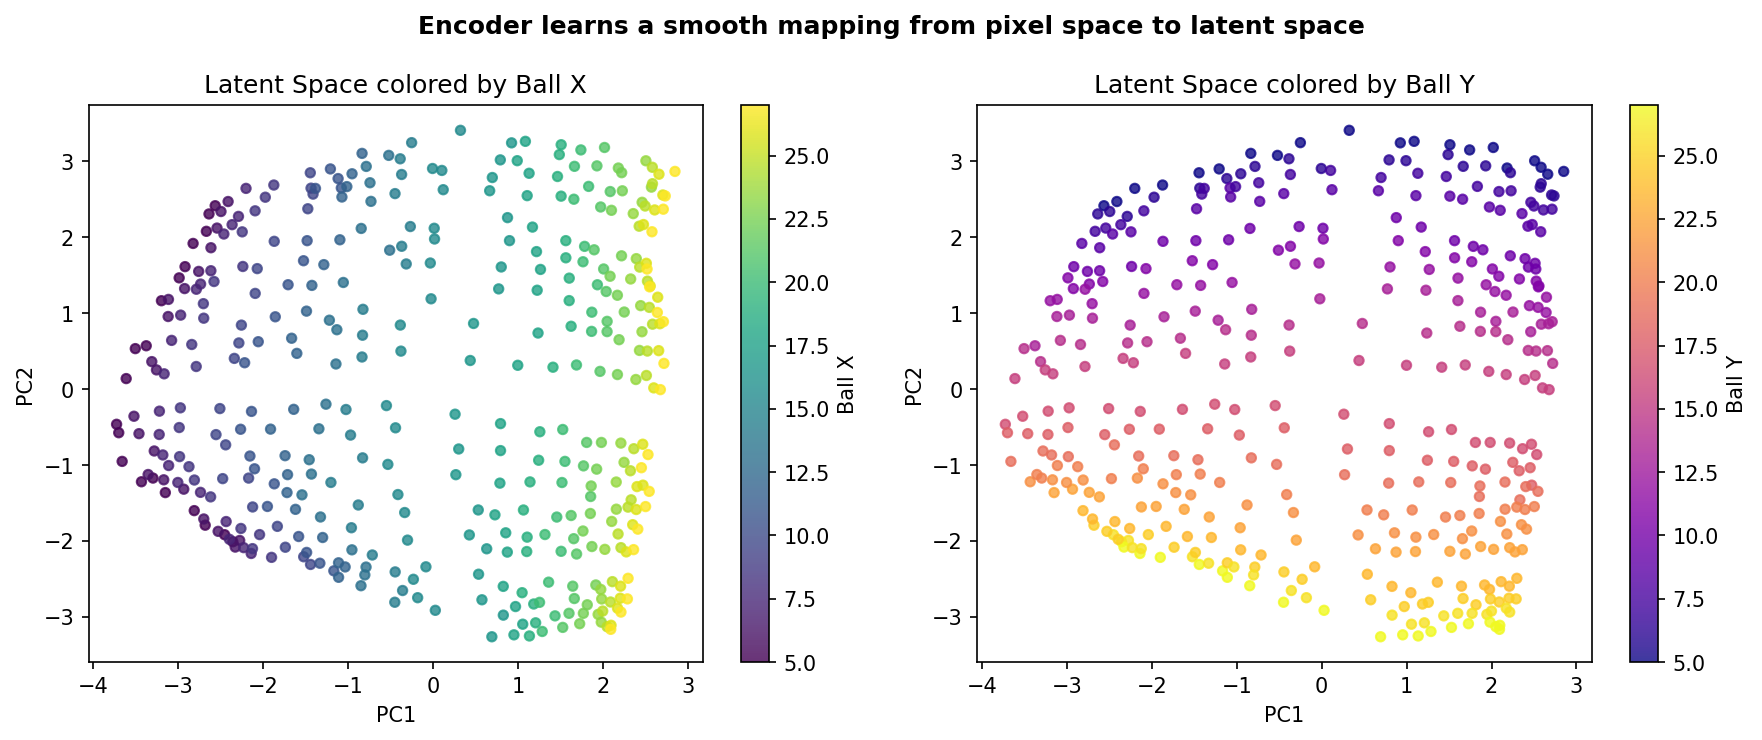

PCA explained variance (top 2 PCs): 48.1%
Smooth color gradients → encoder discovered spatial structure!

In [ ]:
positions = []
latents = []
env = BallWorld()
for x in np.linspace(5, 27, 20):
    for y in np.linspace(5, 27, 20):
        env.x, env.y = x, y
        env.vx, env.vy = 0, 0
        obs = (env._render().flatten() - obs_mean.flatten()) / obs_std.flatten()
        positions.append((x, y))
        latents.append(encoder_good.forward(obs[None, :])[0])

positions = np.array(positions)
latents = np.array(latents)

# PCA via SVD
latents_c = latents - latents.mean(axis=0)
U, S, Vt = np.linalg.svd(latents_c, full_matrices=False)
latents_2d = latents_c @ Vt[:2].T
pca_var = (S[:2] ** 2).sum() / (S**2).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=positions[:, 0],
    cmap="viridis",
    s=20,
    alpha=0.8,
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Latent Space colored by Ball X")
plt.colorbar(sc, ax=axes[0], label="Ball X")

sc = axes[1].scatter(
    latents_2d[:, 0],
    latents_2d[:, 1],
    c=positions[:, 1],
    cmap="plasma",
    s=20,
    alpha=0.8,
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Latent Space colored by Ball Y")
plt.colorbar(sc, ax=axes[1], label="Ball Y")

plt.suptitle(
    "Encoder learns a smooth mapping from pixel space to latent space",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"PCA explained variance (top 2 PCs): {pca_var:.1%}")
print("Smooth color gradients → encoder discovered spatial structure!")

## Section 10: Planning in Latent Space (Random Shooting)

The whole point of learning a world model: **use it to plan**. Given a start state and a goal state, we:
1. Encode both into latent space
2. Generate many random action sequences
3. Simulate each sequence using the predictor (no real environment needed!)
4. Pick the sequence whose final predicted state is closest to the goal

This is **random shooting** — the simplest planning algorithm. Real systems use CEM (Cross-Entropy Method) or gradient-based optimization through the model. Even with this naive approach, the world model enables basic goal-directed behavior.

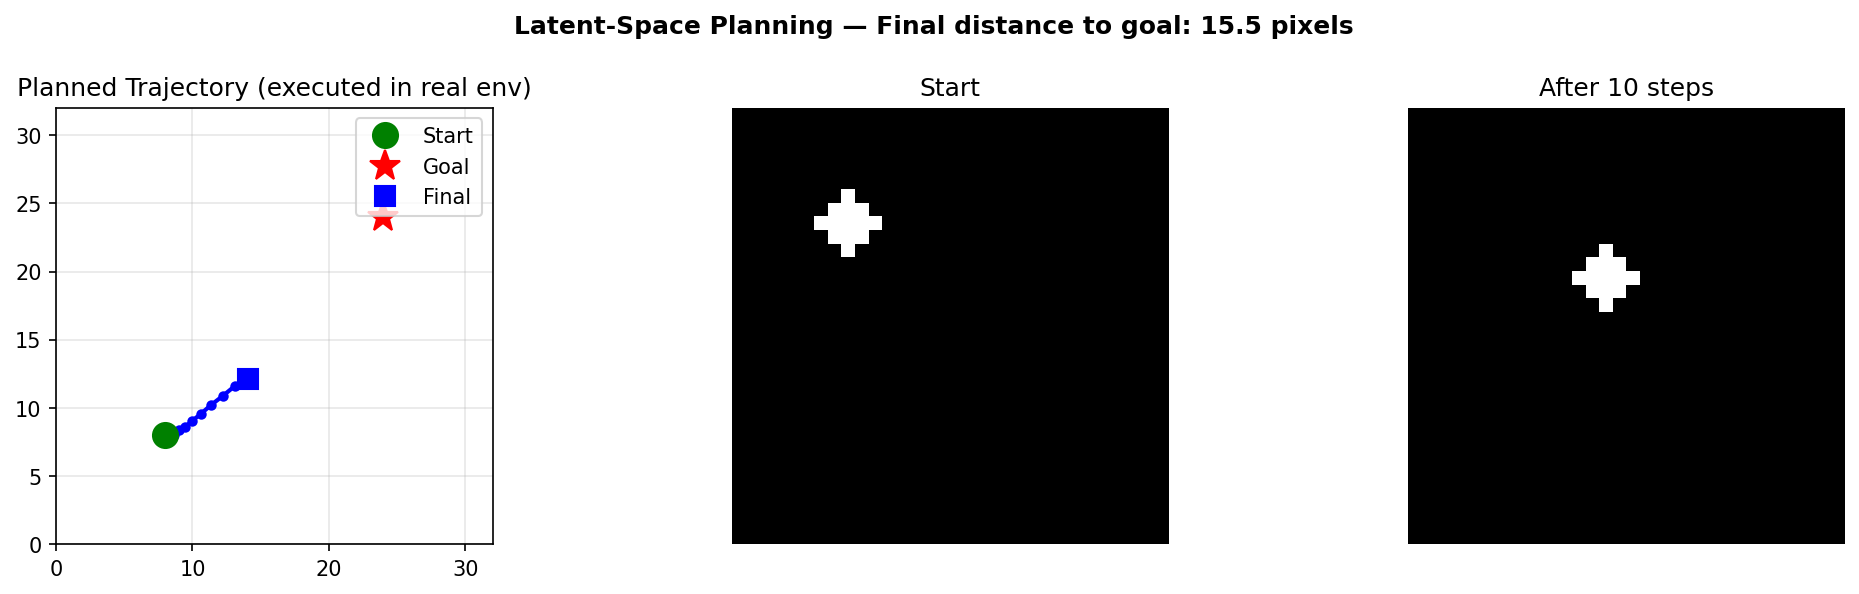

Plan found! Cost: 1.1551

Final position: (14.1, 12.1)
Goal position:  (24.0, 24.0)
Distance:       15.5 pixels (of 22.6 max diagonal)

In [ ]:
def plan_to_goal(enc, pred, start_obs, goal_obs, n_candidates=500, horizon=10):
    """Random shooting planner in latent space."""
    s_norm = (start_obs.flatten() - obs_mean.flatten()) / obs_std.flatten()
    g_norm = (goal_obs.flatten() - obs_mean.flatten()) / obs_std.flatten()
    z_start = enc.forward(s_norm[None, :])
    z_goal = enc.forward(g_norm[None, :])
    best_actions, best_cost = None, float("inf")
    for _ in range(n_candidates):
        actions = np.random.randn(horizon, 2).astype(np.float32) * 0.5
        z = z_start.copy()
        for t in range(horizon):
            inp = np.concatenate([z, actions[t : t + 1]], axis=1)
            z = pred.forward(inp)
        cost = ((z - z_goal) ** 2).mean()
        if cost < best_cost:
            best_cost = cost
            best_actions = actions.copy()
    return best_actions, best_cost


# Plan: move ball from (8,8) to (24,24)
env = BallWorld()
env.x, env.y, env.vx, env.vy = 8, 8, 0, 0
start_obs = env._render()
env.x, env.y, env.vx, env.vy = 24, 24, 0, 0
goal_obs = env._render()

np.random.seed(SEED)
planned_actions, plan_cost = plan_to_goal(
    encoder_good, predictor_good, start_obs, goal_obs
)
print(f"Plan found! Cost: {plan_cost:.4f}")

# Execute in real environment
env.x, env.y, env.vx, env.vy = 8, 8, 0, 0
trajectory = [(env.x, env.y)]
frames = [env._render()]
for t in range(len(planned_actions)):
    env.step(planned_actions[t].tolist())
    trajectory.append((env.x, env.y))
    frames.append(env._render())
trajectory = np.array(trajectory)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(trajectory[:, 0], trajectory[:, 1], "b.-", linewidth=2, markersize=8)
axes[0].plot(8, 8, "go", markersize=12, label="Start")
axes[0].plot(24, 24, "r*", markersize=15, label="Goal")
axes[0].plot(trajectory[-1, 0], trajectory[-1, 1], "bs", markersize=10, label="Final")
axes[0].set_xlim(0, 32)
axes[0].set_ylim(0, 32)
axes[0].set_aspect("equal")
axes[0].legend()
axes[0].set_title("Planned Trajectory (executed in real env)")
axes[0].grid(True, alpha=0.3)
axes[1].imshow(frames[0], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Start")
axes[1].axis("off")
axes[2].imshow(frames[-1], cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"After {len(planned_actions)} steps")
axes[2].axis("off")

final_dist = math.sqrt((trajectory[-1, 0] - 24) ** 2 + (trajectory[-1, 1] - 24) ** 2)
plt.suptitle(
    f"Latent-Space Planning — Final distance to goal: {final_dist:.1f} pixels",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\nFinal position: ({trajectory[-1, 0]:.1f}, {trajectory[-1, 1]:.1f})")
print(f"Goal position:  (24.0, 24.0)")
print(f"Distance:       {final_dist:.1f} pixels (of 22.6 max diagonal)")

## Section 11: Engineering Notes — From Toy to Real

How does our toy compare to the real LeWorldModel?

| Aspect | Our Toy | Real LeWM |
|--------|---------|-----------|
| **Parameters** | 143K | ~15M |
| **Encoder** | MLP (2 layers) | CNN (ResNet-style) |
| **Predictor** | MLP (3 layers) | MLP (similar) |
| **Latent dim** | 32 | 256 |
| **Regularizer** | SIGReg (simplified) | SIGReg (full Cramér-Wold) |
| **Optimizer** | Adam (manual NumPy) | Adam (PyTorch) |
| **Training data** | 10K transitions | 100K+ transitions |
| **Task** | Ball physics | Push-T (block pushing) |
| **Planning** | Random shooting | Random shooting / CEM |
| **Result** | Learns position structure | 96% success rate |

**Key insight from our experiment:** Even at 143K parameters with pure NumPy, the collapse phenomenon is clearly visible. The encoder collapses to near-zero embeddings (std: 0.85 → 0.02) without SIGReg, while SIGReg maintains meaningful representations. This confirms LeWM's core claim: SIGReg is essential for stable JEPA training.

**What we learned about the backprop implementation:**
- The encoder appears on *both sides* of the prediction loss, requiring careful cache management during backward passes
- In-place gradient updates (`dW[:] = ...` not `dW = ...`) are critical when references are shared with optimizers
- Input normalization is essential for gradient flow with sparse binary observations

## Connection to Self-Improving AI (W10–W12 Series)

If you've been following our RSI series, representation collapse might feel familiar. It should — it's structurally the same problem as **reward hacking** in self-play:

| RSI / Self-Play (W10–W12) | World Models / JEPA (W13) |
|---|---|
| Reward hacking: agent finds shortcut that scores high but doesn't improve | Representation collapse: encoder maps everything to zero, prediction loss is trivially low |
| Verification-based filtering catches cheating | SIGReg forces diverse representations |
| Self-play without verification degenerates | JEPA without regularization collapses |
| ASIM: self-improving world models | LeWM: stable JEPA from pixels |

The deeper connection: **both problems arise because optimization finds the path of least resistance**. In self-play, that's gaming the reward. In JEPA, that's collapsing the representation. The solution in both cases is a constraint that forces the system to actually solve the problem rather than circumventing it.

This is why the [ICLR 2026 RSI Workshop paper on ASIM](https://arxiv.org/abs/2503.12862) (Autonomous Self-Improving World Models) sits at the intersection of both fields — it applies RSI principles to prevent world model degradation during self-improvement loops.

## Key Takeaways

1. **JEPA world models predict in latent space, not pixel space** — this is fundamentally cheaper and more robust than generative approaches (the Sora shutdown on March 24 underscores this point)

2. **Representation collapse is the central failure mode** — without regularization, the encoder takes the trivial shortcut of mapping everything to near-zero vectors

3. **SIGReg prevents collapse** by forcing the embedding distribution toward a standard Gaussian, using the elegant Cramér-Wold theorem to test marginal distributions

4. **Lower prediction loss ≠ better model** — the collapsed model achieves lower MSE precisely because it's learned the trivial solution. Always monitor embedding spread alongside loss

5. **Manual backprop reveals the subtleties** — the shared encoder requires careful cache management, and in-place gradient updates matter when optimizer references are shared

6. **The encoder discovers meaningful structure** — even our 143K-parameter toy learns a smooth mapping from 1024-pixel space to 32-dim latent space that captures ball position

7. **Planning works through the world model** — random shooting in latent space enables goal-directed behavior without any explicit reward function

---

**Next:** NB 01 explores JEPA latent dynamics and planning in more detail, building on this foundation with a deeper analysis of what the predictor learns about physics.

**Paper:** [LeWorldModel](https://arxiv.org/abs/2603.19312) · [Code](https://github.com/lucas-maes/le-wm) · [AMI Labs](https://amilabs.xyz/)